# loading the csv data

i just want to get a feeling of what we are working with.

In [61]:
import pandas as pd

# Read the CSV file
df_original = pd.read_csv('data/embeddings/cleaned_data_resnet18_face_embeddings.csv')

# Output the first 5 rows
print("First 5 rows:")
print(df_original.head(5))


First 5 rows:
   Unnamed: 0     emb_0     emb_1     emb_2     emb_3     emb_4     emb_5  \
0           0  1.055535  0.133661  0.897673  1.097033  0.601506  0.417272   
1           1  0.000000  0.237881  1.509098  0.640314  0.039206  0.076827   
2           2  0.151744  0.488820  1.103299  0.309695  0.140026  0.042446   
3           3  0.974255  0.603028  0.577853  0.156421  0.176245  0.148384   
4           4  0.002800  1.001909  0.561875  0.373724  0.331607  0.234691   

      emb_6     emb_7     emb_8  ...   emb_504   emb_505   emb_506   emb_507  \
0  2.309882  0.329897  0.118694  ...  1.224009  1.097021  1.693049  1.875436   
1  0.239381  0.611422  0.049045  ...  0.618985  0.125834  3.581824  0.120598   
2  0.137338  0.540814  0.148879  ...  0.235187  0.232520  2.171654  0.823837   
3  0.943647  0.907221  0.185337  ...  0.771660  1.937275  3.520219  1.859427   
4  0.156683  0.920501  0.491701  ...  1.206913  1.085480  2.976072  0.836052   

    emb_508   emb_509   emb_510   emb_511 

the first 5 images. 0 labels, aka real images. there are 515 columns. I will want to rename 'unnamed: 0, the label, and image path at some point.

In [62]:
# Output the middle 5 rows
n = len(df_original)
start = n // 2 - 2
end = start + 5
print("\nMiddle 5 rows:")
print(df_original.iloc[start:end])


Middle 5 rows:
      Unnamed: 0     emb_0     emb_1     emb_2     emb_3     emb_4     emb_5  \
4998        4998  0.066182  1.486724  0.739907  0.068240  0.250491  0.435512   
4999        4999  0.453779  1.245186  0.680553  0.412460  0.350381  0.007404   
5000        5000  0.303614  1.514825  0.653840  0.102715  0.012765  0.041859   
5001        5001  0.017114  1.590227  0.544775  0.129558  0.263593  0.115635   
5002        5002  0.267174  0.672243  0.651690  0.717590  0.079249  0.142080   

         emb_6     emb_7     emb_8  ...   emb_504   emb_505   emb_506  \
4998  0.149478  0.518318  0.516141  ...  1.138142  0.231947  1.876811   
4999  0.313916  0.614570  0.754118  ...  0.262720  0.736791  2.576199   
5000  1.236077  0.155979  0.166380  ...  0.533406  0.208664  2.952171   
5001  0.345298  0.560072  0.208163  ...  0.601414  0.758663  3.165571   
5002  0.845240  0.352804  0.616890  ...  0.752497  0.475796  3.634730   

       emb_507   emb_508   emb_509   emb_510   emb_511  label  \

5000 real images confirmed 


In [63]:
df = df_original.drop(columns=['Unnamed: 0', 'image_path'])

In [4]:

# Output the last 5 rows
print("\nLast 5 rows:")
print(df.tail(5))


Last 5 rows:
         emb_0     emb_1     emb_2     emb_3     emb_4     emb_5     emb_6  \
9995  0.523880  0.301694  0.663162  0.005417  0.321072  0.000000  0.894520   
9996  0.095835  0.639917  0.867071  0.332126  0.412214  0.179256  0.044235   
9997  0.075518  1.813237  1.304245  0.119125  0.006673  0.058000  0.000000   
9998  0.180334  0.084889  0.337975  1.076868  0.313187  0.108298  0.269600   
9999  0.063316  1.652280  1.534995  0.323399  0.092863  0.172496  0.240777   

         emb_7     emb_8     emb_9  ...   emb_503   emb_504   emb_505  \
9995  0.420411  0.075267  0.210840  ...  0.027997  1.053622  0.932218   
9996  0.193735  0.277987  0.438793  ...  0.527025  0.880230  0.672522   
9997  0.033574  0.537245  0.097389  ...  1.485989  0.684055  0.610250   
9998  0.991926  1.039715  0.002734  ...  0.234076  0.788916  0.614776   
9999  0.911658  0.248647  0.043029  ...  0.928629  0.090011  0.313891   

       emb_506   emb_507   emb_508   emb_509   emb_510   emb_511  label  
9995

looking at the fake images we have the same 515 columns

In [5]:
# Select embedding columns
emb_cols = [col for col in df.columns if col.startswith('emb_')]

# Compute sum of squares for each row
df['sum_squares'] = (df[emb_cols] ** 2).sum(axis=1)

# Compute the average of the sum of squares across all rows
average_sum_squares = df['sum_squares'].mean()

print(f"Average sum of squares across rows: {average_sum_squares}")

Average sum of squares across rows: 468.8619514200655


/var/folders/tt/tz96nmrs4w96fpdp9bltn99r0000gn/T/ipykernel_61578/4111821159.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sum_squares'] = (df[emb_cols] ** 2).sum(axis=1)


# scale the data

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is your dataframe, 'emb_cols' are the embedding columns, and 'label' is the target (0 for real, 1 for fake)
X = df[emb_cols]
y = df['label']

# 1. Split first (to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale based ONLY on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Apply that same scaling to the test data
X_test_scaled = scaler.transform(X_test)

print(f"Standardization complete. Training shape: {X_train_scaled.shape}")
print(f"Standardization complete. Test shape: {X_test_scaled.shape}")


Standardization complete. Training shape: (8000, 512)
Standardization complete. Test shape: (2000, 512)


# plot the most important features

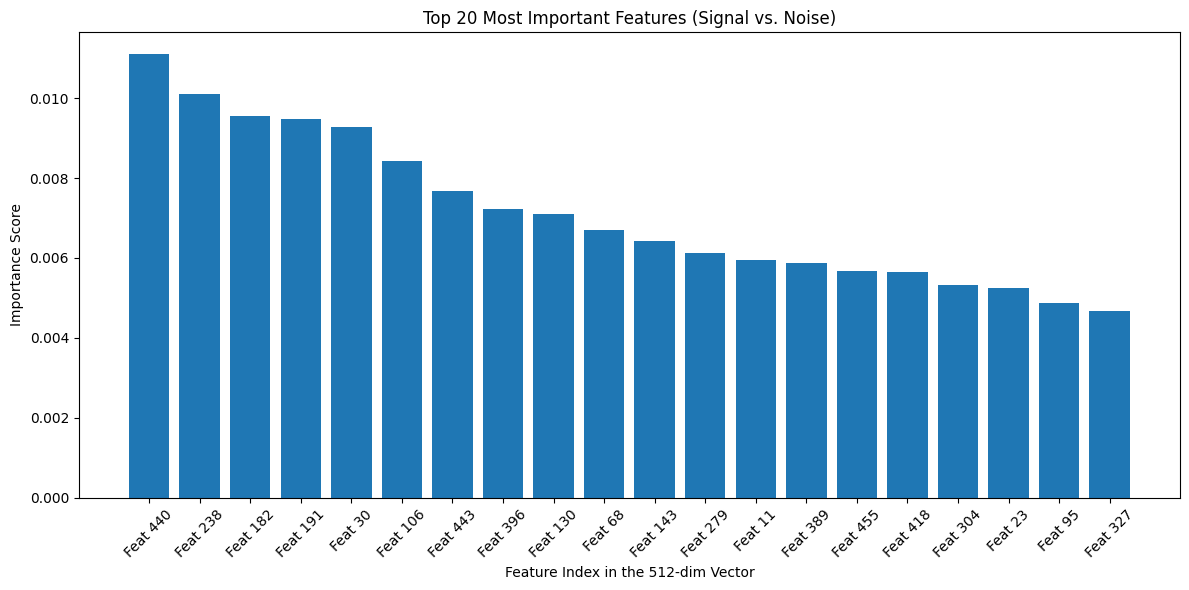

Top feature importance: 0.0111
50th feature importance: 0.0029
500th feature importance: 0.0011


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model
# We use 100 trees; random_state ensures your results are repeatable
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train on the SCALED training data
rf.fit(X_train_scaled, y_train)

# 3. Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sort them from highest to lowest

# 4. Visualize the Top 20 features
plt.figure(figsize=(12, 6))
plt.title("Top 20 Most Important Features (Signal vs. Noise)")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), [f"Feat {i}" for i in indices[:20]], rotation=45)
plt.ylabel("Importance Score")
plt.xlabel("Feature Index in the 512-dim Vector")
plt.tight_layout()
plt.show()

# 5. Check the "Drop-off"
print(f"Top feature importance: {importances[indices[0]]:.4f}")
print(f"50th feature importance: {importances[indices[49]]:.4f}")
print(f"500th feature importance: {importances[indices[499]]:.4f}")

# how many features are important? 

Optimal number of features to keep: 212


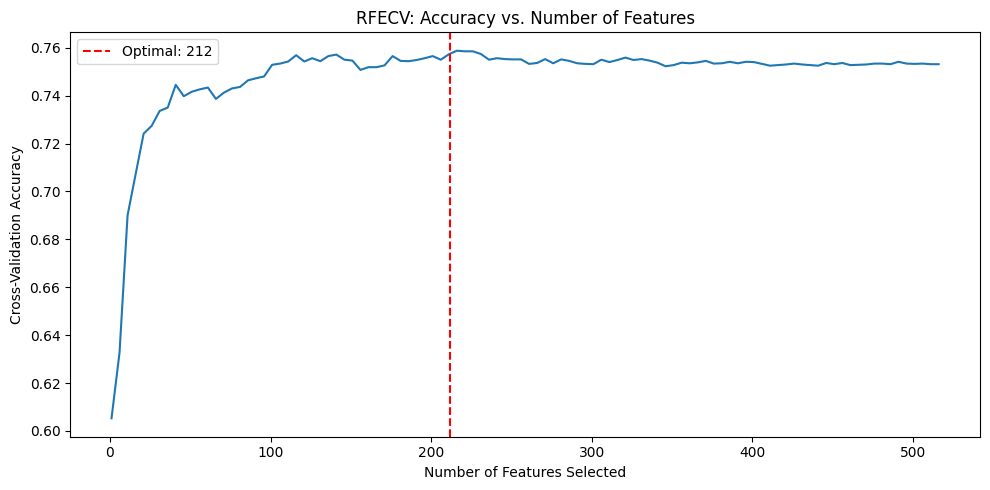

In [8]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 1. Initialize a fast, linear model
# max_iter is set high to ensure it converges on high-dimensional data
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Set up RFECV
# step=5 means it drops 5 features at a time to speed things up
# cv=5 means it uses 5-fold cross-validation to ensure the results are robust
selector = RFECV(estimator=log_reg, step=5, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Fit the selector on your SCALED training data
selector.fit(X_train_scaled, y_train)

# 4. The Results!
optimal_features = selector.n_features_
print(f"Optimal number of features to keep: {optimal_features}")

# 5. Visualize the accuracy as features are removed
plt.figure(figsize=(10, 5))
plt.title("RFECV: Accuracy vs. Number of Features")
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
# cv_results_['mean_test_score'] contains the accuracy at each step
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) * 5 + 1, 5), 
         selector.cv_results_['mean_test_score'])
plt.axvline(x=optimal_features, color='r', linestyle='--', label=f'Optimal: {optimal_features}')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Save the winning columns for the next step
# selector.support_ is a boolean array (True for keep, False for drop)
X_train_optimal = X_train_scaled[:, selector.support_]
X_test_optimal = X_test_scaled[:, selector.support_]

the algorithm says we should choose 212. but looking at the first 100 features, there is a mini peak at about .75. 212 is only marginally better. 

In [9]:
import numpy as np
from scipy.signal import find_peaks

# 1. Extract the scores and the corresponding number of features
scores = selector.cv_results_['mean_test_score']
# Recreating the x-axis (number of features) from your previous plot
feature_counts = np.array(list(range(1, len(scores) * 5 + 1, 5)))

# Point A: The Global Optimal (Should be 212)
optimal = selector.n_features_

# Point B: Max of the first 150 features
# Filter for indices where feature count is <= 150
under_150_indices = np.where(feature_counts <= 150)[0]
scores_under_150 = scores[under_150_indices]
max_under_150_idx = under_150_indices[np.argmax(scores_under_150)]
features_max_150 = feature_counts[max_under_150_idx]

# Point C: The "Mini Spike" (First prominent local maximum)
# find_peaks identifies local highs in the array
peaks, _ = find_peaks(scores)
if len(peaks) > 0:
    # Get the very first peak (the early spike)
    first_peak_idx = peaks[0]
    mini_spike_features = feature_counts[first_peak_idx]
else:
    mini_spike_features = "No distinct spike found"

print("--- The 3 Feature Counts to Test ---")
print(f"1. Global Optimal: {optimal} features")
print(f"2. Max of first 150: {features_max_150} features")
print(f"3. First 'Mini Spike': {mini_spike_features} features")

--- The 3 Feature Counts to Test ---
1. Global Optimal: 212 features
2. Max of first 150: 141 features
3. First 'Mini Spike': 41 features


212 is the global optimal number of features. 141 and 41 are also interesting candidates.

In [10]:
from sklearn.feature_selection import RFE

# 1. Use the same Logistic Regression model from before
# We set n_features_to_select=1 to force it to rank ALL 512 features
ranker = RFE(estimator=log_reg, n_features_to_select=1, step=1)
ranker.fit(X_train_scaled, y_train)

# 2. Get the rankings (1 is the best feature, 512 is the worst)
# np.argsort sorts the rankings and returns the original column indices
ranked_indices = np.argsort(ranker.ranking_)

# 3. Slice your three specific sets
top_41_indices = ranked_indices[:41]
top_141_indices = ranked_indices[:141]
top_212_indices = ranked_indices[:212]

# 4. (Optional) Get the actual column names from your original DataFrame
# Replace 'X' with whatever you named your original DataFrame (before scaling)
top_41_names = X.columns[top_41_indices]
top_141_names = X.columns[top_141_indices]
top_212_names = X.columns[top_212_indices]

print(f"Top 5 columns of the 41-feature set: {top_41_names[:5].tolist()}")

Top 5 columns of the 41-feature set: ['emb_106', 'emb_482', 'emb_279', 'emb_182', 'emb_191']


In [ ]:
print(f"Top 5 columns of the 141-feature set: {top_141_names[:5].tolist()}")

Top 5 columns of the 41-feature set: ['emb_106', 'emb_482', 'emb_279', 'emb_182', 'emb_191']


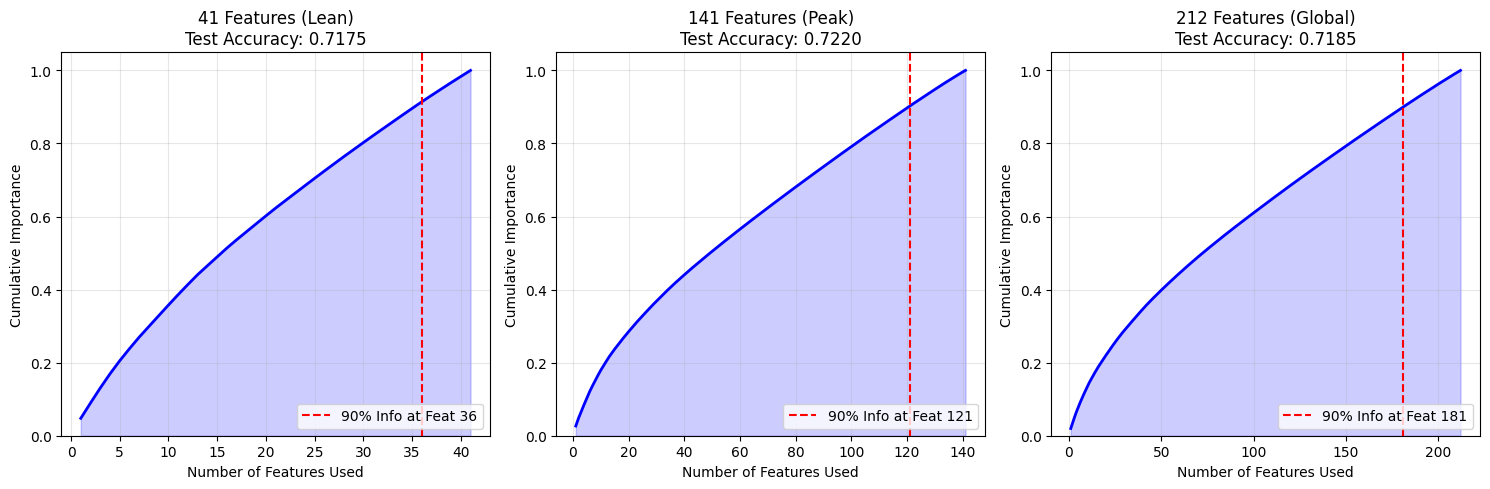

In [12]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# We assume you have top_41_indices, top_141_indices, top_212_indices from the previous step
feature_sets = {
    "41 Features (Lean)": top_41_indices,
    "141 Features (Peak)": top_141_indices,
    "212 Features (Global)": top_212_indices
}

plt.figure(figsize=(15, 5))

for i, (name, indices) in enumerate(feature_sets.items(), 1):
    # 1. Slice the training and testing data for this specific feature set
    X_train_sub = X_train_scaled[:, indices]
    X_test_sub = X_test_scaled[:, indices]
    
    # 2. Train a fresh Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_sub, y_train)
    
    # 3. Evaluate on the UNSEEN test data
    accuracy = rf.score(X_test_sub, y_test)
    
    # 4. Calculate Cumulative Feature Importance (Our proxy for "variance explained")
    importances = rf.feature_importances_
    sorted_importances = np.sort(importances)[::-1] # Sort highest to lowest
    cumulative_importance = np.cumsum(sorted_importances)
    
    # 5. Plot the curve
    plt.subplot(1, 3, i)
    plt.plot(range(1, len(indices) + 1), cumulative_importance, 'b-', linewidth=2)
    plt.fill_between(range(1, len(indices) + 1), cumulative_importance, alpha=0.2, color='blue')
    
    # Draw a line where 90% of the importance is captured
    ninety_percent_idx = np.argmax(cumulative_importance >= 0.90) + 1
    plt.axvline(x=ninety_percent_idx, color='r', linestyle='--', 
                label=f'90% Info at Feat {ninety_percent_idx}')
    
    plt.title(f"{name}\nTest Accuracy: {accuracy:.4f}")
    plt.xlabel("Number of Features Used")
    plt.ylabel("Cumulative Importance")
    plt.ylim(0, 1.05)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# correlate the features

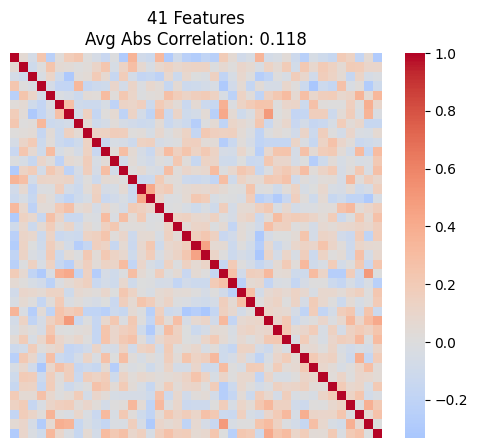

In [13]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 41 Features
indices = top_41_indices
X_subset = X_train_scaled[:, indices]
corr_matrix = np.corrcoef(X_subset, rowvar=False)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
avg_corr = np.mean(np.abs(corr_matrix[mask]))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title(f"41 Features\nAvg Abs Correlation: {avg_corr:.3f}")
plt.show()

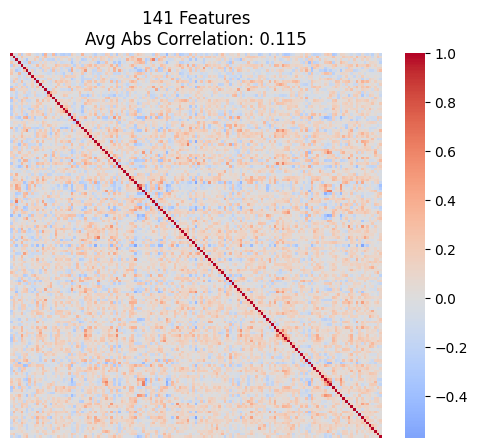

In [14]:
# 141 Features
indices = top_141_indices
X_subset = X_train_scaled[:, indices]
corr_matrix = np.corrcoef(X_subset, rowvar=False)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
avg_corr = np.mean(np.abs(corr_matrix[mask]))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title(f"141 Features\nAvg Abs Correlation: {avg_corr:.3f}")
plt.show()

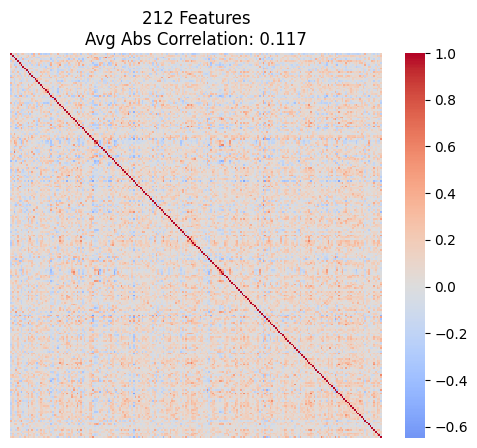

In [15]:
# 212 Features
indices = top_212_indices
X_subset = X_train_scaled[:, indices]
corr_matrix = np.corrcoef(X_subset, rowvar=False)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
avg_corr = np.mean(np.abs(corr_matrix[mask]))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False, cbar=True)
plt.title(f"212 Features\nAvg Abs Correlation: {avg_corr:.3f}")
plt.show()

# visualize the classification rules

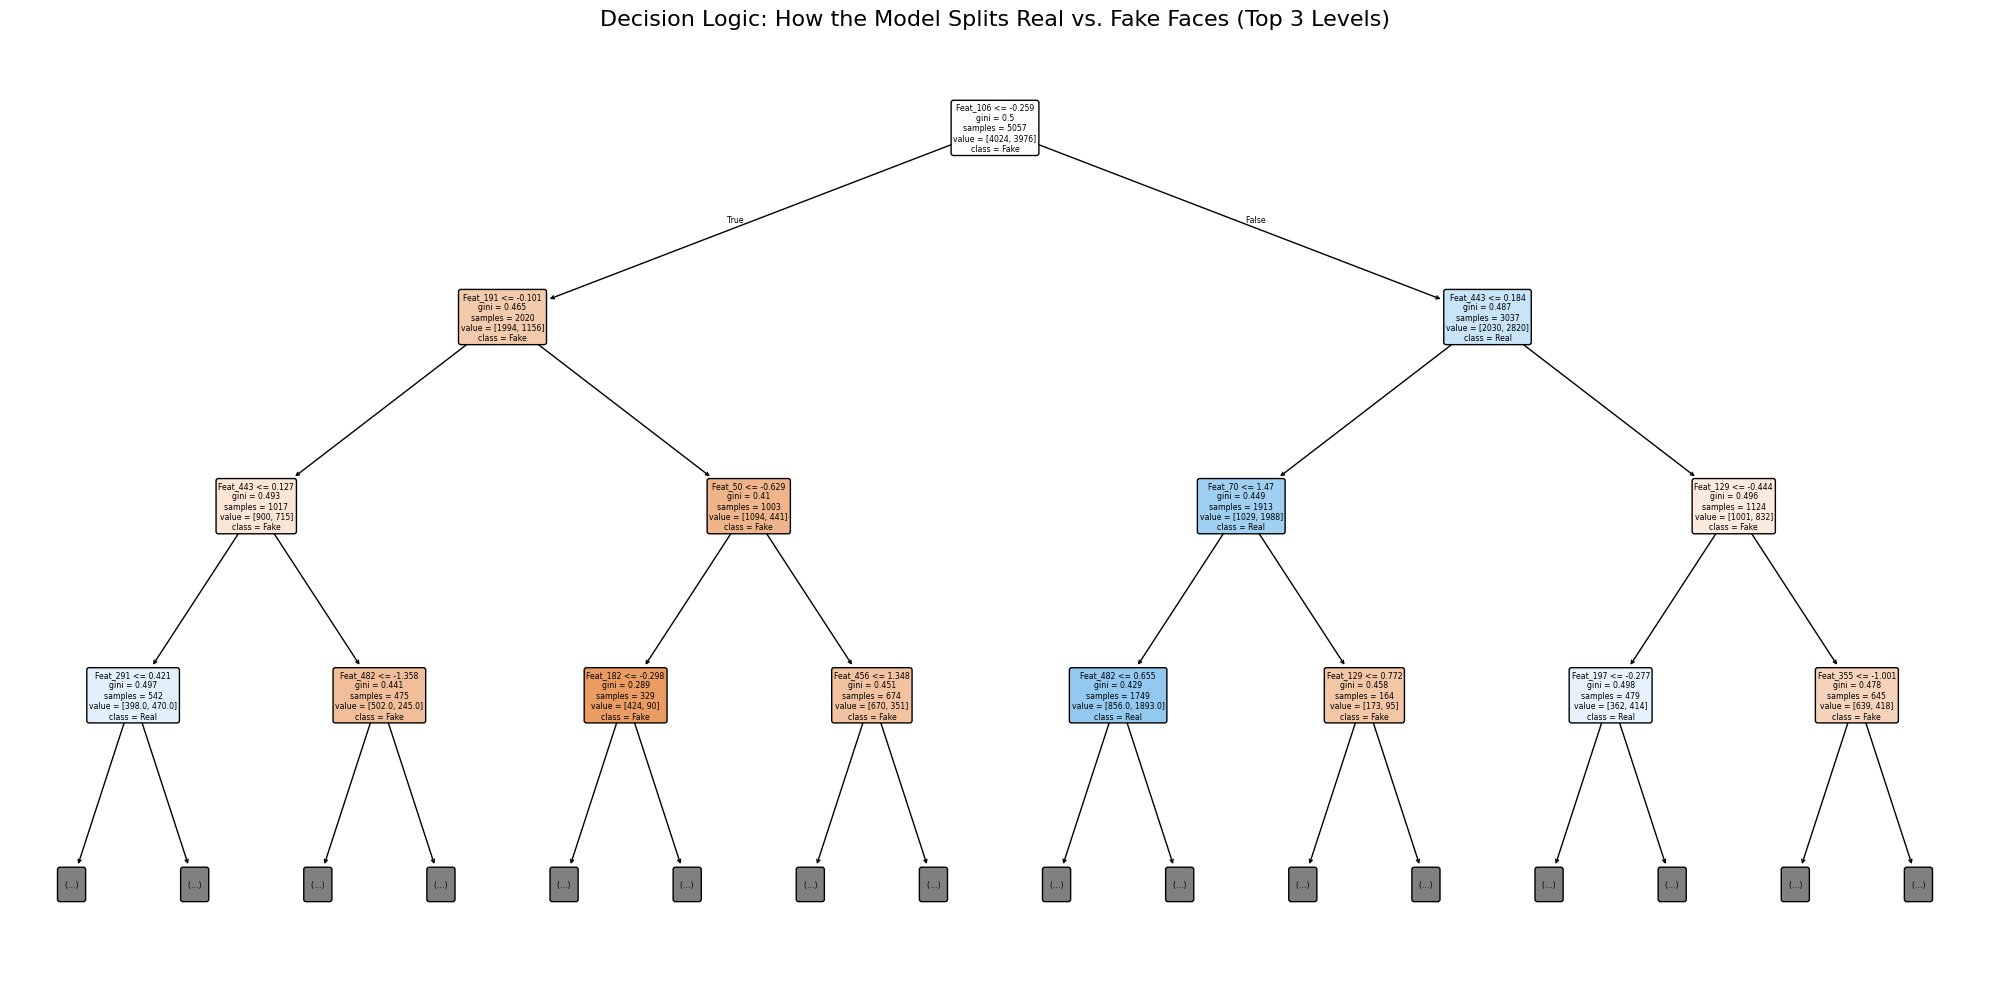

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. Isolate the lean 41-feature dataset
X_train_41 = X_train_scaled[:, top_41_indices]
X_test_41 = X_test_scaled[:, top_41_indices]

# 2. Train a Random Forest specifically on these 41 features
rf_41 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_41.fit(X_train_41, y_train)

# 3. Extract the very first tree from the forest
single_tree = rf_41.estimators_[0]

# 4. Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    single_tree, 
    max_depth=3,                  # Only show top 3 levels so it's readable
    filled=True,                  # Color-codes the nodes (e.g., blue for Real, orange for Fake)
    feature_names=[f"Feat_{i}" for i in top_41_indices], # Uses the actual original column index
    class_names=["Fake", "Real"], # Assumes 0 is Fake, 1 is Real
    rounded=True, 
    proportion=False              # Shows actual sample counts in each box
)
plt.title("Decision Logic: How the Model Splits Real vs. Fake Faces (Top 3 Levels)", fontsize=16)
plt.tight_layout()
plt.show()

# compare accuracy of random forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Organize our three competing feature sets
feature_sets = {
    "The Lean Model (41 Features)": top_41_indices,
    "The Peak Model (141 Features)": top_141_indices,
    "The Global Optimal Model (212 Features)": top_212_indices
}

print("--- Final Test Accuracy Shootout ---\n")

# 2. Loop through each set, train a model, and score it
for name, indices in feature_sets.items():
    
    # Slice the data to only include the specific features for this round
    X_train_final = X_train_scaled[:, indices]
    X_test_final = X_test_scaled[:, indices]
    
    # Initialize a fresh Random Forest
    rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    # Train the model on the training data
    rf_final.fit(X_train_final, y_train)
    
    # Make predictions on the UNSEEN test data
    y_pred = rf_final.predict(X_test_final)
    
    # Calculate the exact accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name}: {acc * 100:.2f}%")

--- Final Test Accuracy Shootout ---

The Lean Model (41 Features): 71.75%
The Peak Model (141 Features): 72.20%
The Global Optimal Model (212 Features): 71.85%


# plot the K-means

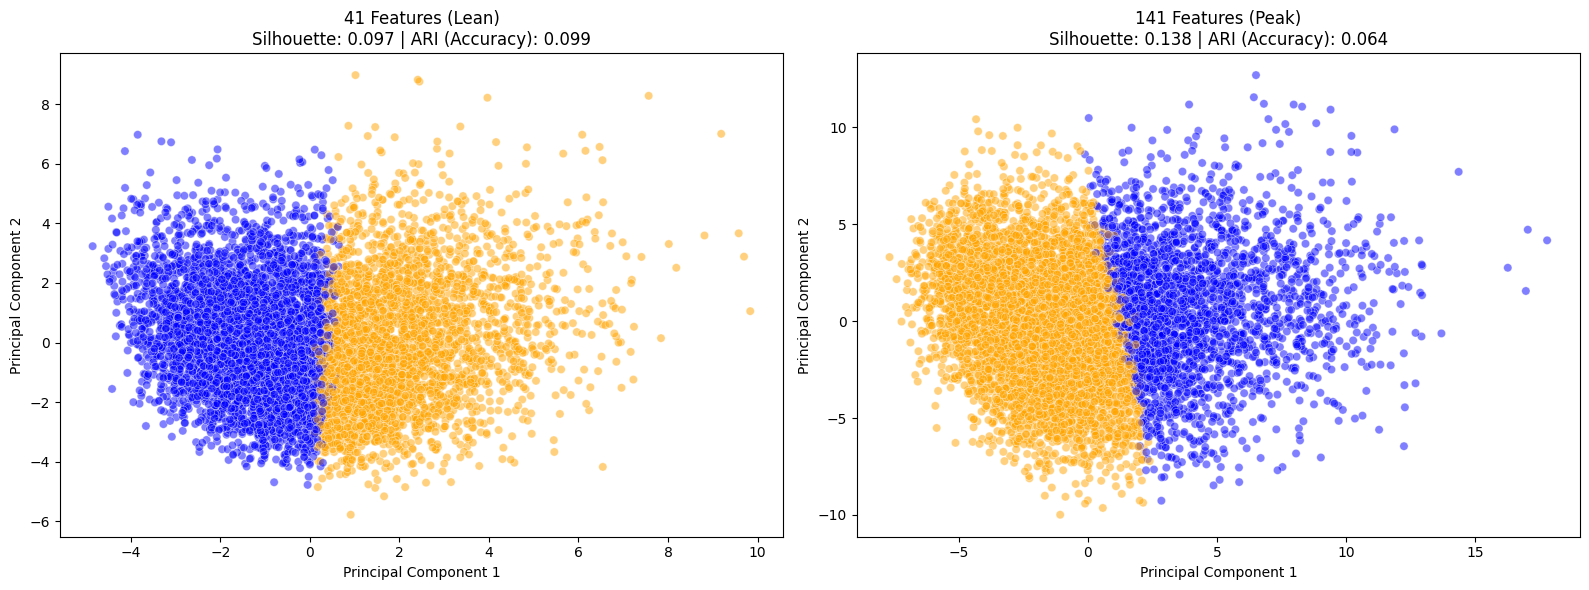

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define our two final contenders
datasets = {
    "41 Features (Lean)": X_train_scaled[:, top_41_indices],
    "141 Features (Peak)": X_train_scaled[:, top_141_indices]
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, data) in enumerate(datasets.items()):
    
    # 2. Run K-Means Clustering (k=2 for Real/Fake)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(data)
    
    # 3. Calculate Scores
    sil_score = silhouette_score(data, cluster_labels)
    ari_score = adjusted_rand_score(y_train, cluster_labels)
    
    # 4. Reduce to 2D for visualization
    pca = PCA(n_components=2, random_state=42)
    data_2d = pca.fit_transform(data)
    
    # 5. Plot the clusters
    sns.scatterplot(x=data_2d[:, 0], y=data_2d[:, 1], hue=cluster_labels, 
                    palette=['blue', 'orange'], alpha=0.5, ax=axes[i], legend=False)
    
    axes[i].set_title(f"{name}\nSilhouette: {sil_score:.3f} | ARI (Accuracy): {ari_score:.3f}")
    axes[i].set_xlabel("Principal Component 1")
    axes[i].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

# plot UMAP (2D)

Running UMAP... (this might take a few seconds)


/opt/homebrew/Caskroom/miniconda/base/envs/truth/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


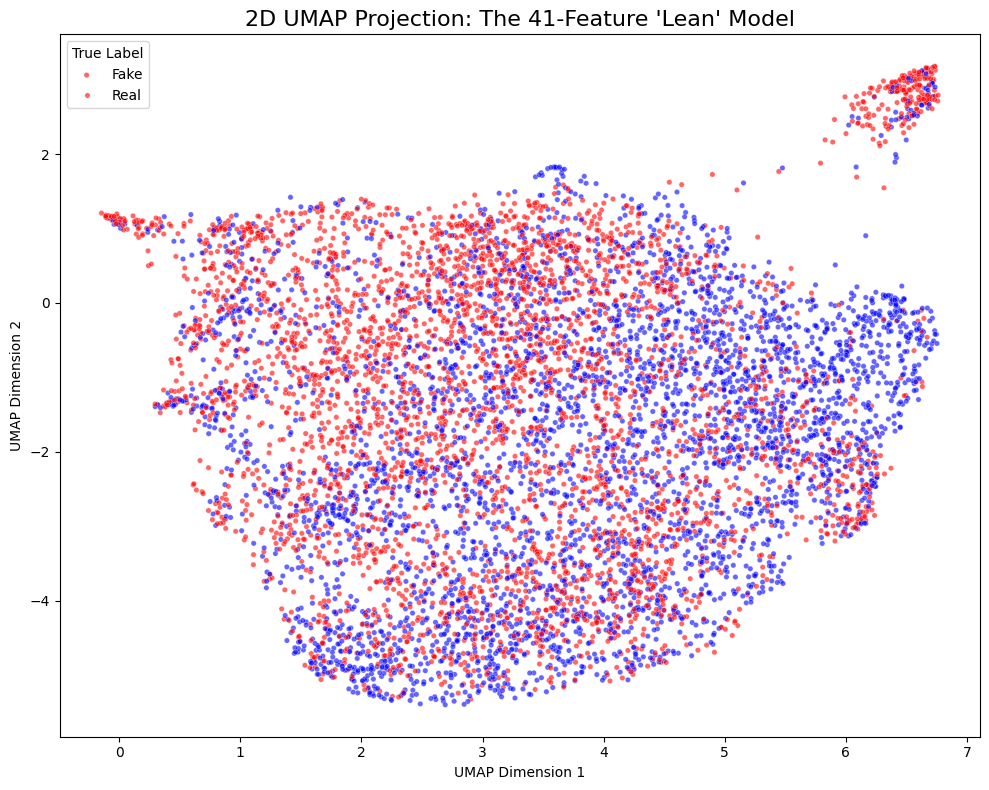

In [22]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize UMAP
# n_neighbors controls the local vs. global structure (15 is a great starting point)
# min_dist controls how tightly points are packed (0.1 helps prevent overlapping blobs)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

# 2. Isolate the winning 41-feature dataset
X_train_41 = X_train_scaled[:, top_41_indices]

# 3. Fit and transform the data into 2 dimensions
print("Running UMAP... (this might take a few seconds)")
umap_2d = reducer.fit_transform(X_train_41)

# 4. Plot the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=umap_2d[:, 0], 
    y=umap_2d[:, 1], 
    hue=y_train,                # Color by your actual labels
    palette=['red', 'blue'], # Adjust colors as you see fit
    alpha=0.6,
    s=15                        # Dot size
)

plt.title("2D UMAP Projection: The 41-Feature 'Lean' Model", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

# Clean up the legend (Assuming 0 is Fake, 1 is Real)
plt.legend(title='True Label', labels=['Fake', 'Real'])
plt.tight_layout()
plt.show()

# plot UMAP (3D)

In [24]:
import umap
import plotly.express as px
import pandas as pd

# 1. Initialize UMAP for 3 Dimensions
# We keep the same neighbors and min_dist so the local structure is identical to your 2D plot
reducer_3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)

# 2. Fit and transform the lean 41-feature dataset
print("Folding into 3D space... (this might take a moment)")
umap_3d = reducer_3d.fit_transform(X_train_41)

# 3. Create a DataFrame for Plotly
# This maps your 0/1 labels to actual text so the legend is easy to read
# (Assuming 1 is Real and 0 is Fake based on standard conventions)
text_labels = ['Real' if label == 1 else 'Fake' for label in y_train]

df_3d = pd.DataFrame({
    'UMAP 1': umap_3d[:, 0],
    'UMAP 2': umap_3d[:, 1],
    'UMAP 3': umap_3d[:, 2],
    'Class': text_labels
})

# 4. Generate the Interactive Plot
fig = px.scatter_3d(
    df_3d, 
    x='UMAP 1', 
    y='UMAP 2', 
    z='UMAP 3',
    color='Class',
    color_discrete_map={'Fake': 'orange', 'Real': 'blue'}, # Keeps colors consistent
    opacity=0.6,                                           # Slightly see-through to spot dense areas
    title="Interactive 3D UMAP: 41-Feature Deepfake Detection"
)

# 5. Polish the visual aesthetics
# Smaller dots (size=3) prevent the 3D space from looking like a giant blob
fig.update_traces(marker=dict(size=3))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# 6. Render the plot!
fig.show()

Folding into 3D space... (this might take a moment)


/opt/homebrew/Caskroom/miniconda/base/envs/truth/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# plot UMAP (3D) with decision boundary

In [26]:
import numpy as np
import plotly.graph_objects as go
from sklearn.svm import SVC

# 1. Train a linear model on the 3D points to find the optimal separating plane
svm_3d = SVC(kernel='linear', C=1.0)
svm_3d.fit(umap_3d, y_train)

# 2. Extract the math for the plane (Weights and Bias)
w = svm_3d.coef_[0]
b = svm_3d.intercept_[0]

# 3. Create a 3D grid to draw the surface
x_min, x_max = umap_3d[:, 0].min(), umap_3d[:, 0].max()
y_min, y_max = umap_3d[:, 1].min(), umap_3d[:, 1].max()

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10),
                     np.linspace(y_min, y_max, 10))

# Calculate Z coordinates for the plane
zz = -(w[0] * xx + w[1] * yy + b) / w[2]

# 4. Build the Interactive Plotly Figure
fig = go.Figure()

# Add the Fake Points (Orange)
fake_mask = y_train == 0
fig.add_trace(go.Scatter3d(
    x=umap_3d[fake_mask, 0], y=umap_3d[fake_mask, 1], z=umap_3d[fake_mask, 2],
    mode='markers', name='Fake',
    marker=dict(size=3, color='orange', opacity=0.6)
))

# Add the Real Points (Blue)
real_mask = y_train == 1
fig.add_trace(go.Scatter3d(
    x=umap_3d[real_mask, 0], y=umap_3d[real_mask, 1], z=umap_3d[real_mask, 2],
    mode='markers', name='Real',
    marker=dict(size=3, color='blue', opacity=0.6)
))

# Add the Translucent Plane
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz,
    name='Decision Boundary',
    colorscale='Greys',
    opacity=0.4,
    showscale=False
))

fig.update_layout(
    title="3D UMAP with SVM Decision Boundary",
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

# confusion matrix on unseen test data for 41 feature model

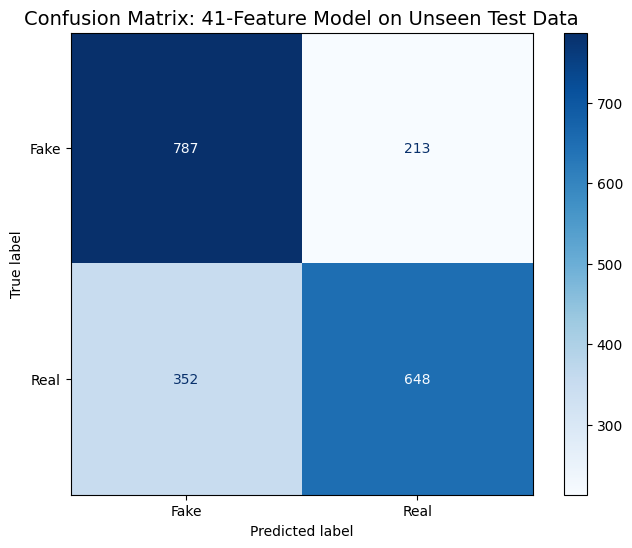


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Fake       0.69      0.79      0.74      1000
        Real       0.75      0.65      0.70      1000

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Ensure we have our test data sliced to the exact 41 features
X_train_41 = X_train_scaled[:, top_41_indices]
X_test_41 = X_test_scaled[:, top_41_indices]

# 2. Train the final Random Forest on the 41 features
final_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
final_rf.fit(X_train_41, y_train)

# 3. Predict the labels for the UNSEEN test data
y_pred = final_rf.predict(X_test_41)

# 4. Create and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d') # 'd' formats numbers as integers
plt.title("Confusion Matrix: 41-Feature Model on Unseen Test Data", fontsize=14)
plt.show()

# 5. Print the detailed scorecard (Precision, Recall, F1)
print("\n--- Detailed Classification Report ---")
# Assuming y_test uses 0 for Fake and 1 for Real
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

# confusion matrix on unseen test data for 141 feature model

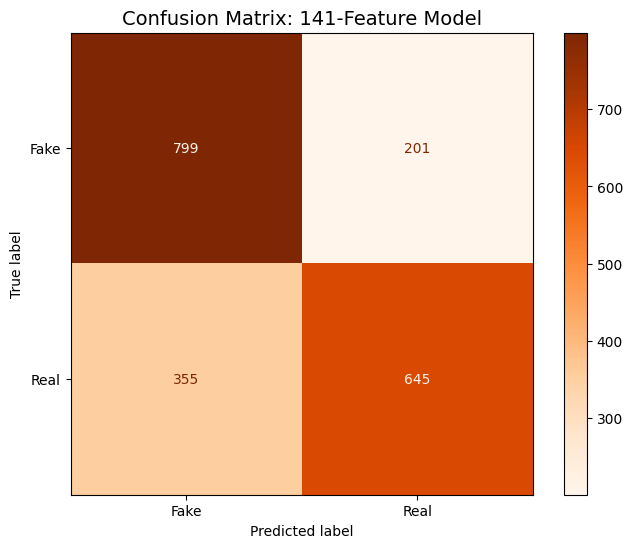


--- 141-Feature Detailed Classification Report ---
              precision    recall  f1-score   support

        Fake       0.69      0.80      0.74      1000
        Real       0.76      0.65      0.70      1000

    accuracy                           0.72      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.73      0.72      0.72      2000



In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Slice the test data to the 141 features
X_train_141 = X_train_scaled[:, top_141_indices]
X_test_141 = X_test_scaled[:, top_141_indices]

# 2. Train the Random Forest on the 141 features
rf_141 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_141.fit(X_train_141, y_train)

# 3. Predict the labels for the UNSEEN test data
y_pred_141 = rf_141.predict(X_test_141)

# 4. Create and plot the Confusion Matrix
cm_141 = confusion_matrix(y_test, y_pred_141)
disp_141 = ConfusionMatrixDisplay(confusion_matrix=cm_141, display_labels=['Fake', 'Real'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_141.plot(cmap='Oranges', ax=ax, values_format='d') # Changed to Orange to differentiate from the 41-model
plt.title("Confusion Matrix: 141-Feature Model", fontsize=14)
plt.show()

# 5. Print the detailed scorecard
print("\n--- 141-Feature Detailed Classification Report ---")
print(classification_report(y_test, y_pred_141, target_names=['Fake', 'Real']))

# roc for 41 feature model

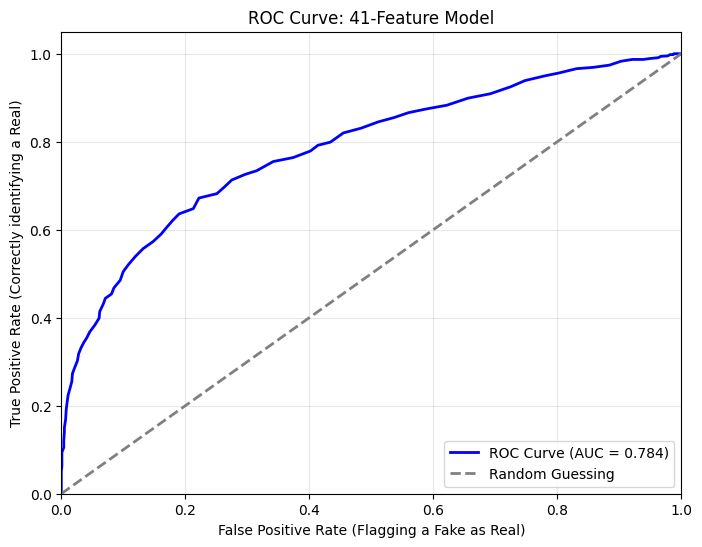

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get the raw probabilities instead of the 0/1 predictions
# predict_proba returns two columns: [Probability of Fake, Probability of Real]
# We want the second column (index 1) for the 'Real' probabilities
y_prob_41 = final_rf.predict_proba(X_test_41)[:, 1]

# 2. Calculate the False Positive Rate, True Positive Rate, and the Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_41)

# 3. Calculate the Area Under the Curve (AUC)
# An AUC of 0.5 is a coin toss; 1.0 is perfect. 
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Flagging a Fake as Real)')
plt.ylabel('True Positive Rate (Correctly identifying a Real)')
plt.title('ROC Curve: 41-Feature Model')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# calculate baseline threshold

In [35]:
import numpy as np

# 1. Calculate Youden's J statistic for every single threshold on the curve
# TPR = True Positive Rate, FPR = False Positive Rate
j_scores = tpr - fpr

# 2. Find the index of the highest J score
optimal_idx = np.argmax(j_scores)

# 3. Grab the exact threshold that corresponds to that highest score
optimal_threshold = thresholds[optimal_idx]

print(f"The default threshold is: 0.500")
print(f"Your mathematical optimal threshold is: {optimal_threshold:.3f}")

# 4. Let's see what the Precision and Recall look like at this new threshold!
# If probability is >= optimal_threshold, label it 1 (Real). Otherwise, 0 (Fake).
y_pred_optimal = (y_prob_41 >= optimal_threshold).astype(int)

from sklearn.metrics import classification_report
print("\n--- Optimized Classification Report ---")
print(classification_report(y_test, y_pred_optimal, target_names=['Fake', 'Real']))

The default threshold is: 0.500
Your mathematical optimal threshold is: 0.500

--- Optimized Classification Report ---
              precision    recall  f1-score   support

        Fake       0.70      0.78      0.74      1000
        Real       0.75      0.67      0.71      1000

    accuracy                           0.72      2000
   macro avg       0.73      0.73      0.72      2000
weighted avg       0.73      0.72      0.72      2000



# run models on 50% threshold


--- Logistic Regression Detailed Report ---
              precision    recall  f1-score   support

        Fake       0.73      0.75      0.74      1000
        Real       0.74      0.72      0.73      1000

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



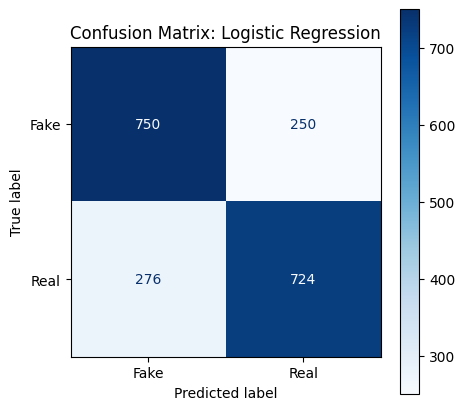


--- Support Vector Machine (SVM) Detailed Report ---
              precision    recall  f1-score   support

        Fake       0.71      0.81      0.76      1000
        Real       0.78      0.68      0.72      1000

    accuracy                           0.74      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.74      0.74      2000



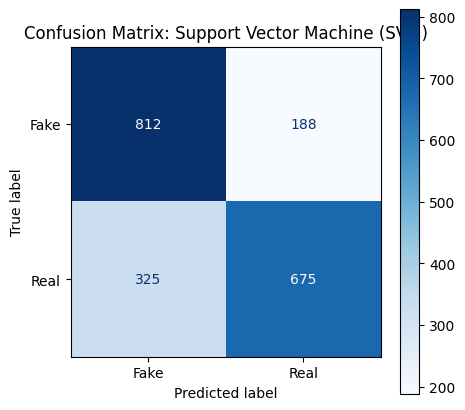


--- XGBoost Detailed Report ---
              precision    recall  f1-score   support

        Fake       0.70      0.76      0.73      1000
        Real       0.73      0.67      0.70      1000

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



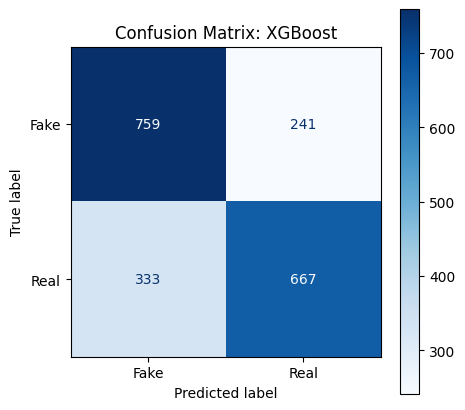

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Ensure the models are trained (using the same 41 features)
for name, model in models.items():
    y_pred = model.predict(X_test_41)
    
    # 1. Print the Text Report (The "Why")
    print(f"\n--- {name} Detailed Report ---")
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
    
    # 2. Plot the Confusion Matrix (The "Where")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# plot thresholds behavior

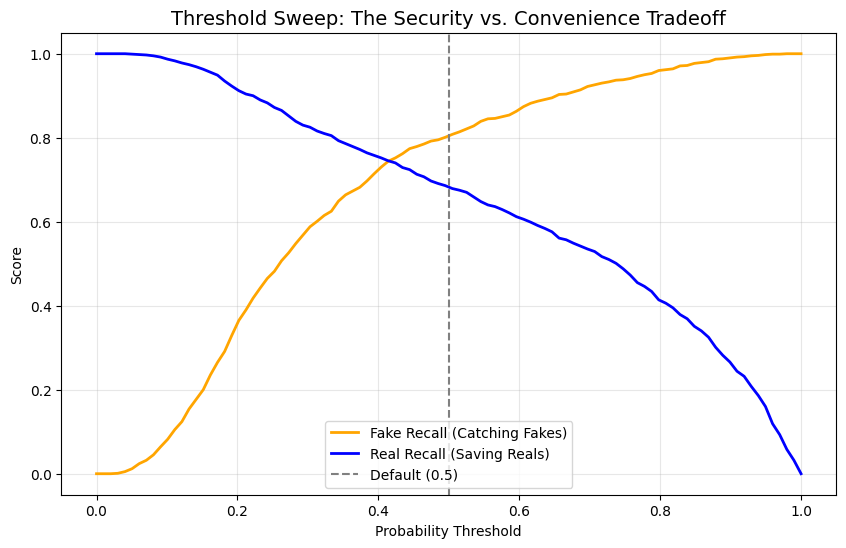

--- Threshold Insights ---
To catch 90% of fakes, set threshold to: 1.000
At this level, your Real Recall (Convenience) drops to: 0.000


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# 1. Get the probabilities for the Real class from our champion SVM
y_probs_svm = models["Support Vector Machine (SVM)"].predict_proba(X_test_41)[:, 1]

# 2. Define a range of thresholds from 0 to 1
thresholds = np.linspace(0, 1, 100)
fake_recalls = []
real_recalls = []
precisions = []

for t in thresholds:
    # Apply threshold: 1 if prob > t, else 0
    y_pred_t = (y_probs_svm >= t).astype(int)
    
    # We care most about catching Fakes (Recall for class 0)
    # and not annoying Real users (Recall for class 1)
    fake_recalls.append(recall_score(y_test, y_pred_t, pos_label=0))
    real_recalls.append(recall_score(y_test, y_pred_t, pos_label=1))

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds, fake_recalls, label='Fake Recall (Catching Fakes)', color='orange', lw=2)
plt.plot(thresholds, real_recalls, label='Real Recall (Saving Reals)', color='blue', lw=2)

plt.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.title('Threshold Sweep: The Security vs. Convenience Tradeoff', fontsize=14)
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Find the "High Security" Threshold
# Let's find the threshold where we catch 90% of fakes
target_recall = 0.90
idx = np.where(np.array(fake_recalls) >= target_recall)[0][-1]
security_threshold = thresholds[idx]

print(f"--- Threshold Insights ---")
print(f"To catch 90% of fakes, set threshold to: {security_threshold:.3f}")
print(f"At this level, your Real Recall (Convenience) drops to: {real_recalls[idx]:.3f}")

# comparision of strategies

In [65]:
# Define our two test thresholds
threshold_balanced = 0.46
threshold_security = 0.67  # Adjust this to 0.75 if you want to be even stricter

# Apply thresholds to the winning SVM probabilities
y_pred_bal = (y_probs_svm >= threshold_balanced).astype(int)
y_pred_sec = (y_probs_svm >= threshold_security).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(f"--- BALANCED STRATEGY (Threshold {threshold_balanced}) ---")
print(classification_report(y_test, y_pred_bal, target_names=['Fake', 'Real']))

print(f"\n--- HIGH-SECURITY STRATEGY (Threshold {threshold_security}) ---")
print(classification_report(y_test, y_pred_sec, target_names=['Fake', 'Real']))

--- BALANCED STRATEGY (Threshold 0.46) ---
              precision    recall  f1-score   support

        Fake       0.73      0.78      0.75      1000
        Real       0.76      0.71      0.73      1000

    accuracy                           0.74      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.74      0.74      2000


--- HIGH-SECURITY STRATEGY (Threshold 0.67) ---
              precision    recall  f1-score   support

        Fake       0.67      0.90      0.77      1000
        Real       0.85      0.56      0.67      1000

    accuracy                           0.73      2000
   macro avg       0.76      0.73      0.72      2000
weighted avg       0.76      0.73      0.72      2000



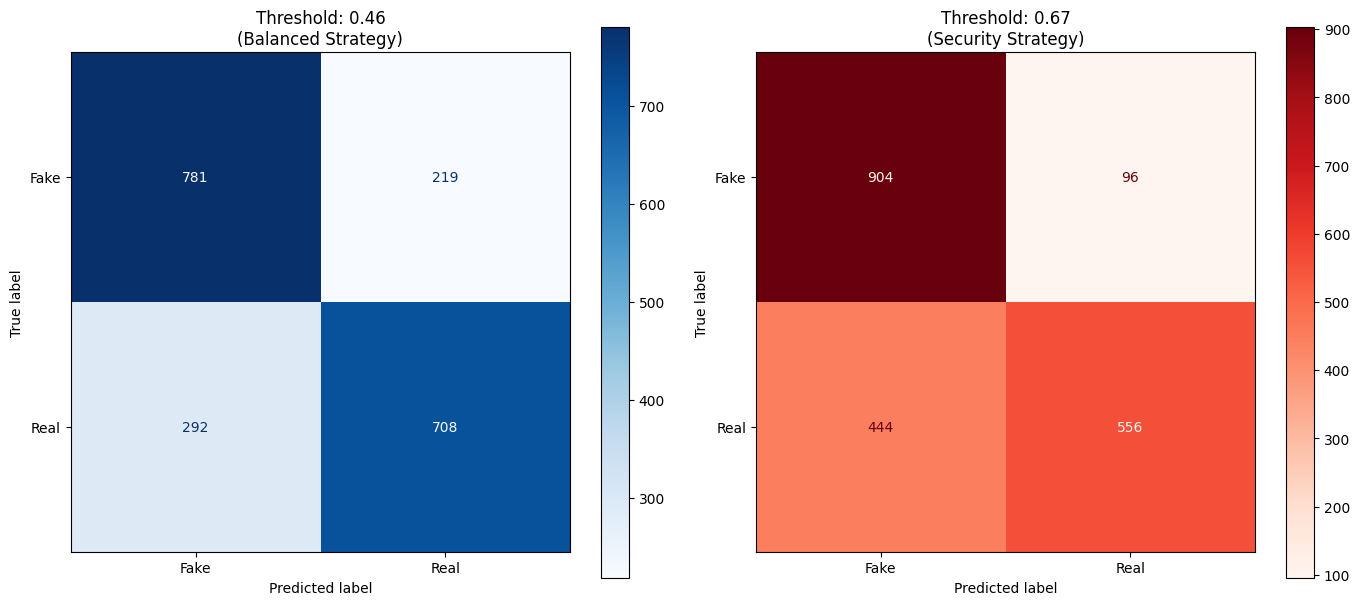

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Access the SVM from your dictionary
# (Ensuring we use the exact key from the shootout code)
champion_svm = models["Support Vector Machine (SVM)"]

# 2. Define the thresholds to compare
thresholds = [0.46, 0.67]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3. Get the probabilities for the 'Real' class
y_probs_svm = champion_svm.predict_proba(X_test_41)[:, 1]

# 4. Plot both matrices
for i, t in enumerate(thresholds):
    # Apply threshold: if prob >= t, it's 'Real' (1), else 'Fake' (0)
    y_pred_t = (y_probs_svm >= t).astype(int)
    
    # Generate matrix
    cm = confusion_matrix(y_test, y_pred_t)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    
    # Plotting with distinct colors to show the change in "mood"
    color = 'Blues' if t == 0.46 else 'Reds'
    disp.plot(cmap=color, ax=axes[i], values_format='d')
    axes[i].set_title(f'Threshold: {t}\n' + ('(Balanced Strategy)' if t == 0.46 else '(Security Strategy)'))

plt.tight_layout()
plt.show()

# who are the 101 who are passing through?

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate thresholds and calculate recalls
thresholds = np.linspace(0.01, 0.99, 100)
tradeoff_data = []

for t in thresholds:
    y_pred_t = (y_probs_svm >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    # tn = Fake caught, fp = Fake missed
    # fn = Real blocked, tp = Real passed
    tradeoff_data.append({
        'Threshold': t,
        'Fakes_Caught': tn,
        'Real_Blocked': fn,
        'Ratio': fn / tn if tn > 0 else 0
    })

df_cost = pd.DataFrame(tradeoff_data)

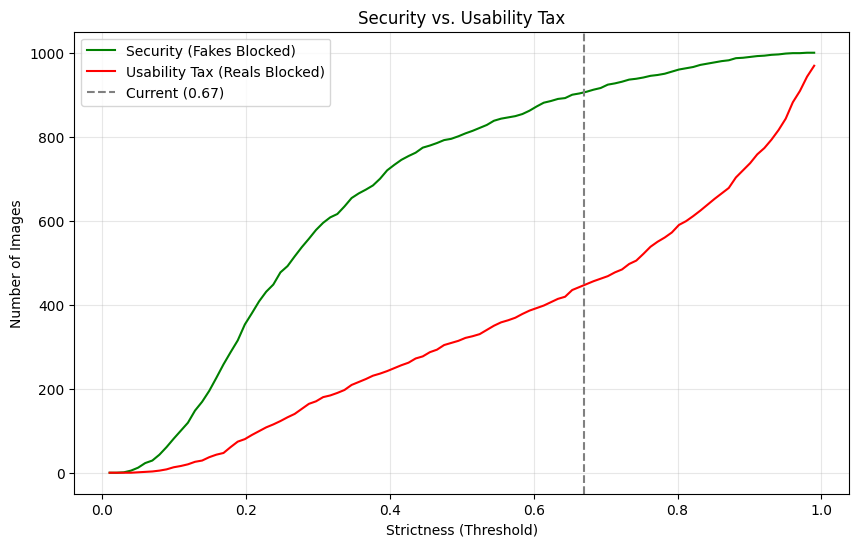

In [55]:
# 2. Plot the "Security Tax"
plt.figure(figsize=(10, 6))
plt.plot(df_cost['Threshold'], df_cost['Fakes_Caught'], label='Security (Fakes Blocked)', color='green')
plt.plot(df_cost['Threshold'], df_cost['Real_Blocked'], label='Usability Tax (Reals Blocked)', color='red')

plt.axvline(0.67, color='gray', linestyle='--', label='Current (0.67)')
plt.title('Security vs. Usability Tax')
plt.xlabel('Strictness (Threshold)')
plt.ylabel('Number of Images')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [50]:
import numpy as np
from sklearn.metrics import roc_curve

# 1. Get ROC components
# Recall: pos_label=1 is 'Real', but we want to catch Fakes (0)
# So we invert the probabilities to treat Fake as the positive class for this math
fpr, tpr, thresholds_roc = roc_curve(y_test, 1 - y_probs_svm, pos_label=0)

# 2. Calculate the "Distance" from the random line (Youden's J-statistic)
# J = TPR - FPR
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
mathematical_optimal = thresholds_roc[best_idx]

# 3. Calculate the "Curvature" (The Second Derivative)
# This finds where the "Elbow" actually is
dy = np.gradient(tpr)
dx = np.gradient(fpr)
slopes = dy / dx

# Find the threshold where slope is closest to 1
elbow_idx = np.argmin(np.abs(slopes - 1.0))
elbow_threshold = thresholds_roc[elbow_idx]

print(f"The 'Max Balance' point (Youden's J): {mathematical_optimal:.3f}")
print(f"The 'Elbow' point (Where slope = 1): {elbow_threshold:.3f}")

The 'Max Balance' point (Youden's J): 0.556
The 'Elbow' point (Where slope = 1): 0.903


/var/folders/tt/tz96nmrs4w96fpdp9bltn99r0000gn/T/ipykernel_61578/310895102.py:19: RuntimeWarning:

divide by zero encountered in divide



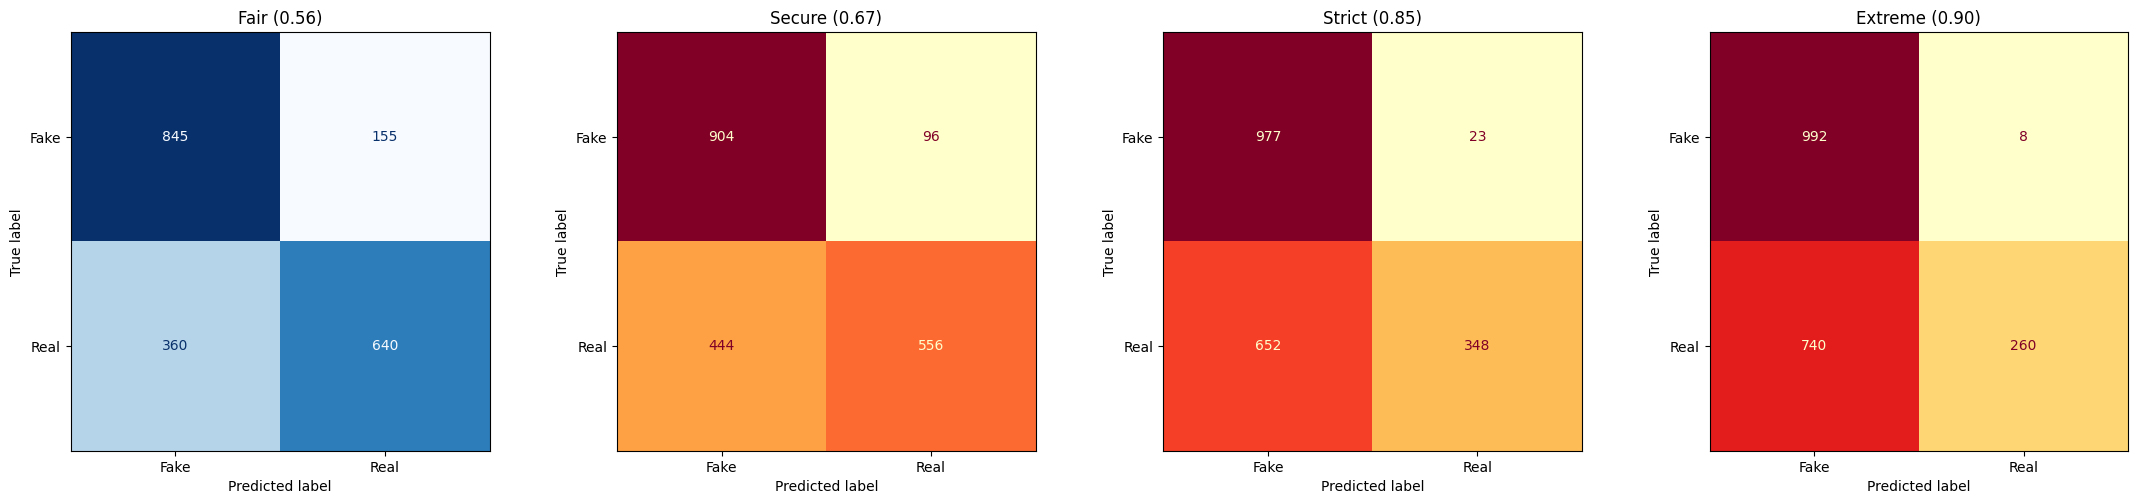

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define our four milestones
test_thresholds = [0.556, 0.67, 0.85, 0.903]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 2. Extract probabilities from the SVM
y_probs_svm = models["Support Vector Machine (SVM)"].predict_proba(X_test_41)[:, 1]

# 3. Iterate and plot
for i, t in enumerate(test_thresholds):
    y_pred_t = (y_probs_svm >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    # Choose color based on strictness
    cmap = 'Blues' if t < 0.6 else 'YlOrRd'
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    disp.plot(cmap=cmap, ax=axes[i], values_format='d', colorbar=False)
    
    # Labeling the "Personality"
    titles = {0.556: "Fair (0.56)", 0.67: "Secure (0.67)", 
              0.85: "Strict (0.85)", 0.903: "Extreme (0.90)"}
    axes[i].set_title(titles.get(t, f"Threshold {t}"))

plt.tight_layout()
plt.show()

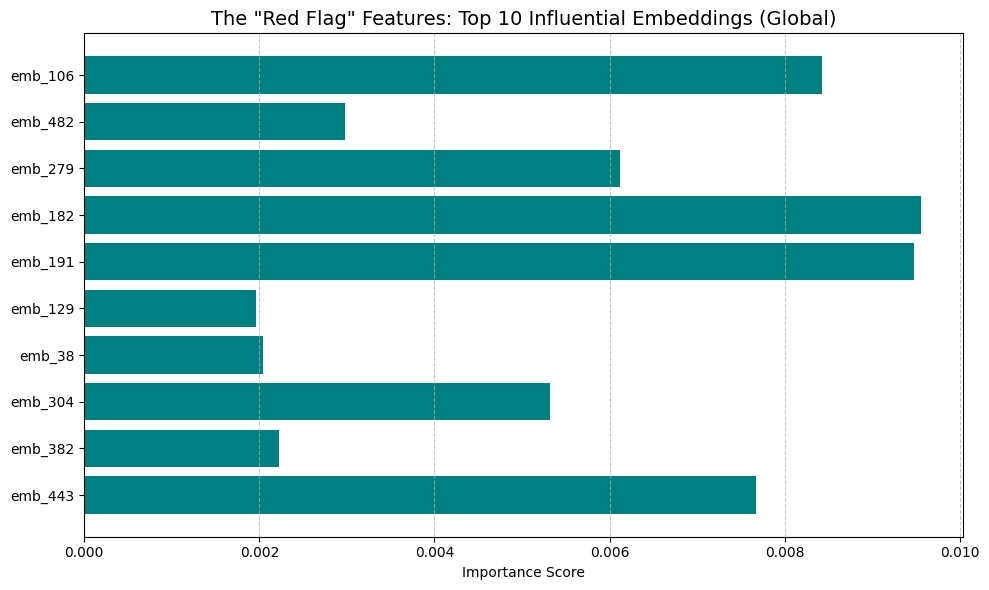

Top 10 Global Features: ['emb_106', 'emb_482', 'emb_279', 'emb_182', 'emb_191', 'emb_129', 'emb_38', 'emb_304', 'emb_382', 'emb_443']


In [64]:
from sklearn.ensemble import RandomForestClassifier

# 1. Re-fit a quick RF on the full 512 set to get the global importances back
rf_global = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_global.fit(X_train_scaled, y_train)
global_importances = rf_global.feature_importances_

# 2. Map the scores using the top_41_indices we already have
top_10_indices = top_41_indices[:10]
top_10_scores = global_importances[top_10_indices]
top_10_names = [f'emb_{i}' for i in top_10_indices]

# 3. Plot the Leaderboard
plt.figure(figsize=(10, 6))
plt.barh(top_10_names[::-1], top_10_scores[::-1], color='teal')
plt.title('The "Red Flag" Features: Top 10 Influential Embeddings (Global)', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 Global Features:", top_10_names)

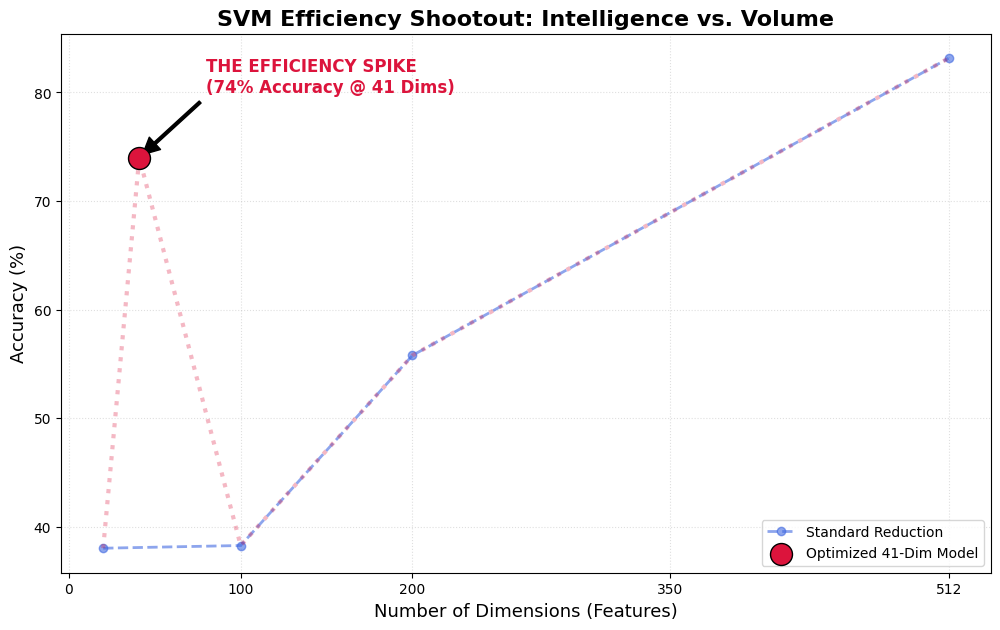

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Preparation
# Teammate's standard dimensionality reduction results
comparison_data = [
    {'Model': 'Standard SVM', 'Dims': 20, 'Accuracy': 38.05},
    {'Model': 'Standard SVM', 'Dims': 100, 'Accuracy': 38.30},
    {'Model': 'Standard SVM', 'Dims': 200, 'Accuracy': 55.80},
    {'Model': 'Standard SVM', 'Dims': 512, 'Accuracy': 83.15}
]

# Your optimized result
optimized_data = [
    {'Model': 'Optimized SVM (41 Features)', 'Dims': 41, 'Accuracy': 74.00}
]

# Combine and sort for the visual sequence
df_combined = pd.DataFrame(comparison_data + optimized_data).sort_values(by='Dims')

plt.figure(figsize=(12, 7))

# 1. Plot the 'Baseline' line (teammate's trajectory)
standard_curve = df_combined[df_combined['Model'] == 'Standard SVM']
plt.plot(standard_curve['Dims'], standard_curve['Accuracy'], 
         label="Standard Reduction", color='royalblue', 
         linestyle='--', marker='o', alpha=0.6, linewidth=2)

# 2. Plot your optimized point as a 'Spike'
plt.scatter(41, 74.00, color='crimson', s=250, label='Optimized 41-Dim Model', zorder=5, edgecolor='black')

# 3. Add the 'Spike' connecting lines to show the anomaly
plt.plot(df_combined['Dims'], df_combined['Accuracy'], color='crimson', alpha=0.3, linestyle=':', linewidth=3)

# 4. Annotate the win
plt.annotate('THE EFFICIENCY SPIKE\n(74% Accuracy @ 41 Dims)', 
             xy=(41, 74.00), xytext=(80, 80),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2),
             fontsize=12, fontweight='bold', color='crimson')

# Formatting
plt.title('SVM Efficiency Shootout: Intelligence vs. Volume', fontsize=16, fontweight='bold')
plt.xlabel('Number of Dimensions (Features)', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.xticks([0, 100, 200, 350, 512], ['0', '100', '200', '350', '512'])
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower right')

plt.show()